# A/B Testing & Uplift Modeling — Hillstrom E-Mail Marketing Dataset
**Phase 1: Data Loading, EDA, Metric Definitions, and Statistical Assumption Checks**

---
## Section 1 — Data Loading & EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

sns.set_theme(style='whitegrid')
%matplotlib inline

# Load data
df = pd.read_csv('../data/hillstrom.csv')

print('=== Dataset Shape ===')
print(df.shape)

print('\n=== Data Types ===')
print(df.dtypes)

print('\n=== First 5 Rows ===')
df.head()

=== Dataset Shape ===
(64000, 12)

=== Data Types ===
recency              int64
history_segment     object
history            float64
mens                 int64
womens               int64
zip_code            object
newbie               int64
channel             object
segment             object
visit                int64
conversion           int64
spend              float64
dtype: object

=== First 5 Rows ===


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0


In [2]:
print('=== Null Counts ===')
print(df.isnull().sum())
print(f'\nTotal nulls: {df.isnull().sum().sum()}')

=== Null Counts ===
recency            0
history_segment    0
history            0
mens               0
womens             0
zip_code           0
newbie             0
channel            0
segment            0
visit              0
conversion         0
spend              0
dtype: int64

Total nulls: 0


In [3]:
print('=== Value Counts: segment (Treatment Column) ===')
print(df['segment'].value_counts())
print()
print(df['segment'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

=== Value Counts: segment (Treatment Column) ===
segment
Womens E-Mail    21387
Mens E-Mail      21307
No E-Mail        21306
Name: count, dtype: int64

segment
Womens E-Mail    33.42%
Mens E-Mail      33.29%
No E-Mail        33.29%
Name: proportion, dtype: object


In [4]:
# Create binary treatment column: 0 = control (No E-Mail), 1 = treatment (any e-mail)
df['treatment'] = (df['segment'] != 'No E-Mail').astype(int)

print('=== Group Sizes: Treatment vs Control ===')
group_sizes = df['treatment'].value_counts().sort_index()
print(f'Control   (treatment=0): {group_sizes[0]:,}')
print(f'Treatment (treatment=1): {group_sizes[1]:,}')
print(f'Total: {len(df):,}')

=== Group Sizes: Treatment vs Control ===
Control   (treatment=0): 21,306
Treatment (treatment=1): 42,694
Total: 64,000


---
## Section 2 — Metric Definition

In [5]:
# Primary metric: conversion rate
# Guardrail metric: visit rate

control = df[df['treatment'] == 0]
treatment = df[df['treatment'] == 1]

control_conversion   = control['conversion'].mean()
treatment_conversion = treatment['conversion'].mean()

control_visit   = control['visit'].mean()
treatment_visit = treatment['visit'].mean()

print('=== PRIMARY METRIC: Conversion Rate ===')
print(f'  Control   conversion rate: {control_conversion:.4f} ({control_conversion*100:.2f}%)')
print(f'  Treatment conversion rate: {treatment_conversion:.4f} ({treatment_conversion*100:.2f}%)')
print(f'  Absolute lift: {(treatment_conversion - control_conversion)*100:+.2f} pp')

print()
print('=== GUARDRAIL METRIC: Visit Rate ===')
print(f'  Control   visit rate: {control_visit:.4f} ({control_visit*100:.2f}%)')
print(f'  Treatment visit rate: {treatment_visit:.4f} ({treatment_visit*100:.2f}%)')
print(f'  Absolute lift: {(treatment_visit - control_visit)*100:+.2f} pp')

=== PRIMARY METRIC: Conversion Rate ===
  Control   conversion rate: 0.0057 (0.57%)
  Treatment conversion rate: 0.0107 (1.07%)
  Absolute lift: +0.50 pp

=== GUARDRAIL METRIC: Visit Rate ===
  Control   visit rate: 0.1062 (10.62%)
  Treatment visit rate: 0.1670 (16.70%)
  Absolute lift: +6.09 pp


---
## Section 3 — Statistical Assumption Checks

In [6]:
# --- Check 1: Group Balance ---
n_control   = group_sizes[0]
n_treatment = group_sizes[1]
ratio = n_control / n_treatment

print('=== CHECK 1: Group Balance ===')
print(f'  Control   n = {n_control:,}')
print(f'  Treatment n = {n_treatment:,}')
print(f'  Ratio (control / treatment) = {ratio:.4f}')

balance_pass = 0.9 <= ratio <= 1.1
print(f'  Result: {"PASS" if balance_pass else "FAIL"} (target ratio 0.90 – 1.10)')

=== CHECK 1: Group Balance ===
  Control   n = 21,306
  Treatment n = 42,694
  Ratio (control / treatment) = 0.4990
  Result: FAIL (target ratio 0.90 – 1.10)


In [7]:
# --- Check 2: Sample Ratio Mismatch (SRM) ---
# Under the null, we expect equal group sizes.
# Use a chi-square goodness-of-fit test on observed vs expected counts.

from scipy.stats import chisquare

total = n_control + n_treatment
expected = total / 2  # equal split expectation

chi2_stat, srm_pvalue = chisquare([n_control, n_treatment], f_exp=[expected, expected])

srm_detected = srm_pvalue < 0.05

print('=== CHECK 2: Sample Ratio Mismatch (SRM) ===')
print(f'  Chi-square statistic: {chi2_stat:.4f}')
print(f'  p-value: {srm_pvalue:.4f}')
print(f'  SRM detected: {srm_detected}')
srm_pass = not srm_detected
print(f'  Result: {"PASS" if srm_pass else "FAIL"} (SRM present if p < 0.05)')

=== CHECK 2: Sample Ratio Mismatch (SRM) ===
  Chi-square statistic: 7147.6022
  p-value: 0.0000
  SRM detected: True
  Result: FAIL (SRM present if p < 0.05)


C:\Users\Sai Spandana\AppData\Local\Temp\ipykernel_40968\3804904983.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Group', y='history', ax=axes[1],


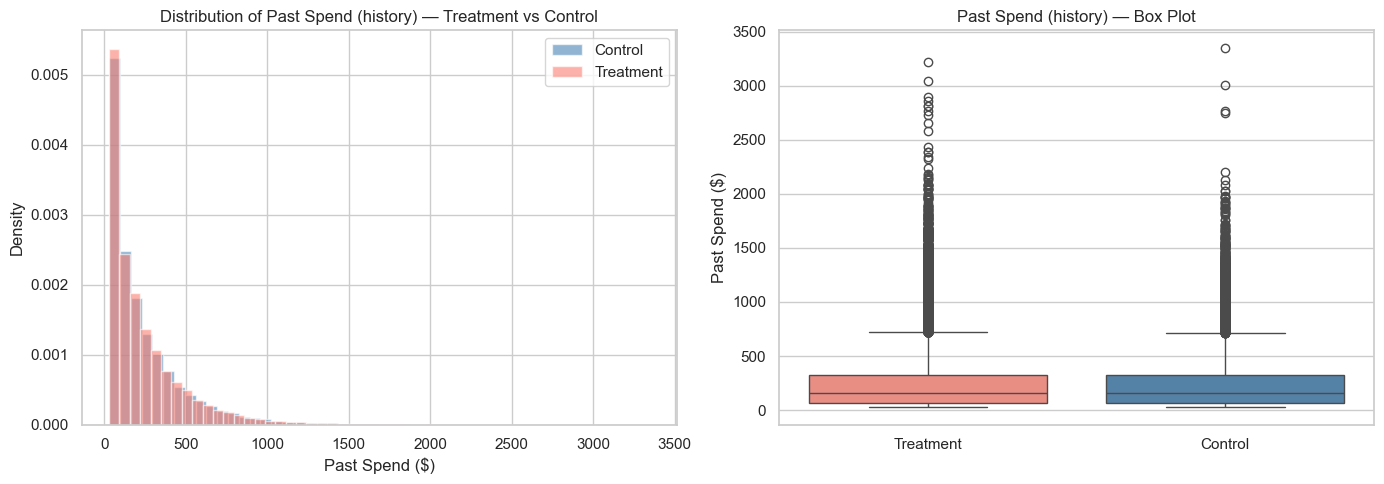


=== CHECK 3: History (Past Spend) Summary Statistics ===
             count    mean     std    min    25%     50%     75%      max
Control    21306.0  240.88  252.74  29.99  65.30  156.66  325.17  3345.93
Treatment  42694.0  242.69  257.85  29.99  64.35  158.87  325.78  3215.97

  Mean difference: 0.75%
  Result: PASS (mean difference < 5% threshold)


In [8]:
# --- Check 3: Distribution check on 'history' (past spend) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(control['history'], bins=50, alpha=0.6, label='Control', color='steelblue', density=True)
axes[0].hist(treatment['history'], bins=50, alpha=0.6, label='Treatment', color='salmon', density=True)
axes[0].set_title('Distribution of Past Spend (history) — Treatment vs Control')
axes[0].set_xlabel('Past Spend ($)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Box plot for side-by-side comparison
df_plot = df[['history', 'treatment']].copy()
df_plot['Group'] = df_plot['treatment'].map({0: 'Control', 1: 'Treatment'})
sns.boxplot(data=df_plot, x='Group', y='history', ax=axes[1],
            palette={'Control': 'steelblue', 'Treatment': 'salmon'})
axes[1].set_title('Past Spend (history) — Box Plot')
axes[1].set_xlabel('')
axes[1].set_ylabel('Past Spend ($)')

plt.tight_layout()
plt.savefig('../data/history_distribution_check.png', dpi=100, bbox_inches='tight')
plt.show()

# Numeric summary for distribution comparison
hist_summary = df.groupby('treatment')['history'].describe().round(2)
hist_summary.index = ['Control', 'Treatment']
print('\n=== CHECK 3: History (Past Spend) Summary Statistics ===')
print(hist_summary)

mean_diff_pct = abs(control['history'].mean() - treatment['history'].mean()) / control['history'].mean() * 100
dist_pass = mean_diff_pct < 5
print(f'\n  Mean difference: {mean_diff_pct:.2f}%')
print(f'  Result: {"PASS" if dist_pass else "FAIL"} (mean difference < 5% threshold)')

In [9]:
# --- Assumption Checks Summary ---
print('\n' + '='*50)
print('  ASSUMPTION CHECKS SUMMARY')
print('='*50)
print(f'  Check 1 — Group Balance:              {"PASS" if balance_pass else "FAIL"}')
print(f'  Check 2 — Sample Ratio Mismatch:      {"PASS" if srm_pass else "FAIL"}')
print(f'  Check 3 — History Distribution:       {"PASS" if dist_pass else "FAIL"}')
print('='*50)


  ASSUMPTION CHECKS SUMMARY
  Check 1 — Group Balance:              FAIL
  Check 2 — Sample Ratio Mismatch:      FAIL
  Check 3 — History Distribution:       PASS


---
## Section 4 — Phase 1 Summary

In [10]:
conversion_lift = (treatment_conversion - control_conversion) * 100
visit_lift      = (treatment_visit - control_visit) * 100

print('=' * 60)
print('  PHASE 1 COMPLETE — SUMMARY REPORT')
print('=' * 60)
print()
print(f'  Dataset          : Hillstrom E-Mail Marketing (2008)')
print(f'  Total records    : {len(df):,}')
print()
print('  GROUP SIZES')
print(f'    Control   (No E-Mail) : {n_control:,} ({n_control/len(df)*100:.1f}%)')
print(f'    Treatment (E-Mail)    : {n_treatment:,} ({n_treatment/len(df)*100:.1f}%)')
print()
print('  CONVERSION RATE (Primary Metric)')
print(f'    Control   : {control_conversion*100:.2f}%')
print(f'    Treatment : {treatment_conversion*100:.2f}%')
print(f'    Lift      : {conversion_lift:+.2f} percentage points')
print()
print('  VISIT RATE (Guardrail Metric)')
print(f'    Control   : {control_visit*100:.2f}%')
print(f'    Treatment : {treatment_visit*100:.2f}%')
print(f'    Lift      : {visit_lift:+.2f} percentage points')
print()
print('  ASSUMPTION CHECKS')
print(f'    Group Balance (ratio {ratio:.3f})       : {"PASS" if balance_pass else "FAIL"}')
print(f'    Sample Ratio Mismatch (p={srm_pvalue:.3f}) : {"PASS" if srm_pass else "FAIL"}')
print(f'    History Distribution (diff={mean_diff_pct:.2f}%) : {"PASS" if dist_pass else "FAIL"}')
print()
print('  Next: Phase 2 — Hypothesis testing, confidence intervals,')
print('        and power analysis.')
print('=' * 60)

  PHASE 1 COMPLETE — SUMMARY REPORT

  Dataset          : Hillstrom E-Mail Marketing (2008)
  Total records    : 64,000

  GROUP SIZES
    Control   (No E-Mail) : 21,306 (33.3%)
    Treatment (E-Mail)    : 42,694 (66.7%)

  CONVERSION RATE (Primary Metric)
    Control   : 0.57%
    Treatment : 1.07%
    Lift      : +0.50 percentage points

  VISIT RATE (Guardrail Metric)
    Control   : 10.62%
    Treatment : 16.70%
    Lift      : +6.09 percentage points

  ASSUMPTION CHECKS
    Group Balance (ratio 0.499)       : FAIL
    Sample Ratio Mismatch (p=0.000) : FAIL
    History Distribution (diff=0.75%) : PASS

  Next: Phase 2 — Hypothesis testing, confidence intervals,
        and power analysis.
